# Four Decades of Fire

**Landsat over the Iberian Peninsula, 1985-2024, and why the obvious statistic lies**

Iberia burns. The question people ask after a bad summer is whether it burns *more* than it
used to, and forty years of Landsat is exactly the archive that ought to answer it: the
Normalized Burn Ratio drops sharply when vegetation is consumed, it has been computable on
every Landsat since 1984, and Earth Engine holds the whole peninsula.

This notebook tries to build that answer decade by decade — 1985-94, 1995-2004, 2005-14,
2015-24 — and spends most of its length on the three ways the obvious version of it goes
wrong:

1. **The reducer.** Over ten years, every pixel has one terrible observation. A decade
   minimum of NBR is a map of the worst cloud shadow, not of fire.
2. **The archive.** There are three times as many usable Landsat scenes over Iberia in the
   last decade as in the first, and 2.6 times as many clear looks at the average pixel. A
   statistic built on extremes moves with that, so the naive comparison manufactures a
   trend of its own.
3. **The land cover.** At peninsular scale the biggest seasonal drops in NBR are not fires.
   They are harvests.

Each one is measured here rather than asserted, and each has a fix that costs almost
nothing once it is named.

Three of those fixes work. The fourth thing — putting one decade next to another — does
not survive them, and section 8 shows why on a single pair of axes: the four decades line
up against how often the satellite looked at them, not against anything that happened on
the ground. **That is the result of this notebook.** The maps of where Iberia burned are
good inside each decade; the series across them is a property of the archive, and saying
so is worth more than the trend it was supposed to produce.

> **Cost warning.** This notebook composites tens of thousands of Landsat scenes over
> 580 000 km². A full run is about forty minutes of Earth Engine time and will make a dent in
> a monthly quota. Every section says what it costs, and the `REGION` switch in section 1
> runs the whole thing over one province in a few minutes.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import time

import ee
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality

# ee.Authenticate()          # only the first time
PROJECT = 'your-project-id'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine initialised')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


✓ Earth Engine initialised


The ROI is Spain, Portugal and Andorra, clipped to the peninsula: the Canaries fall outside
the bounding box and the Balearics are subtracted, so "Iberian Peninsula" means what it
says.

**Set `REGION = 'culebra'` to run the whole notebook over one 30 × 55 km box instead.** It
is the same code on a hundredth of the area, and it is how the figures below were checked
before the full run.

In [2]:
REGION = 'peninsula'          # or 'culebra', for a fast pass over a single fire

IBERIA = ee.Geometry.Rectangle([-9.6, 35.9, 3.4, 43.9])
BALEARES = ee.Geometry.Rectangle([0.9, 38.3, 4.5, 40.3])
PENINSULA = (ee.FeatureCollection('FAO/GAUL/2015/level0')
             .filter(ee.Filter.inList('ADM0_NAME', ['Spain', 'Portugal', 'Andorra']))
             .geometry().intersection(IBERIA, 1000).difference(BALEARES, 1000))

# Sierra de la Culebra, Zamora: about 25 000 ha burned between 15 and 18 June 2022,
# the largest Spanish fire in decades and the validation case of section 3
CULEBRA = ee.Geometry.Rectangle([-6.60, 41.80, -6.05, 42.10])

ROI = PENINSULA if REGION == 'peninsula' else CULEBRA
DECADES = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2024)]
LABELS = ['%d-%d' % (a, b) for a, b in DECADES]

print('%s: %.0f km²' % (REGION, ROI.area(5000).getInfo() / 1e6))

peninsula: 581788 km²


In [3]:
# one look for every figure: a single-hue ramp for magnitude, a diverging pair with a
# neutral middle for change, and the Okabe-Ito hues wherever a line needs an identity
BURN = ['2b1a4a', '7b2d6f', 'c74b4b', 'f0913c', 'fde3a7']    # dark -> hot
CHANGE = ['08519c', '6baed6', 'e8e8e8', 'fd8d3c', 'a63603']
HUES = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
INK, MUTED = '#222222', '#777777'
HALO = [pe.withStroke(linewidth=2.2, foreground='white')]

plt.style.use('default')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#cccccc', 'axes.labelcolor': INK,
                     'axes.facecolor': 'white', 'figure.facecolor': 'white',
                     'savefig.facecolor': 'white', 'axes.grid': False,
                     'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'grid.color': '#e8e8e8', 'grid.linewidth': 0.8,
                     'font.size': 9, 'figure.dpi': 110})


def thumbnail(image, vis, region=None, dimensions=620):
    """An EE image as an RGBA array, at whatever size the figure needs."""
    url = image.visualize(**vis).getThumbURL(
        {'region': region if region is not None else ROI, 'dimensions': dimensions,
         'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))


def ramp_legend(ax, palette, ticks, labels):
    """A horizontal colour bar built from an Earth Engine palette."""
    colours = mpl.colors.LinearSegmentedColormap.from_list(
        'ramp', ['#' + colour for colour in palette])
    ax.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=colours)
    ax.set_yticks([])
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.tick_params(length=0, labelsize=7.5, colors=MUTED)
    for spine in ax.spines.values():
        spine.set_visible(False)

## 2. The archive is not the same in every decade

Before any index is computed, the thing that will bias every comparison: how much Landsat
there actually is. The scene counts come from the catalogue metadata, so this cell is cheap
whatever `REGION` is set to.

In [4]:
SENSORS = ['LANDSAT/LT04/C02/T1_L2', 'LANDSAT/LT05/C02/T1_L2',
           'LANDSAT/LE07/C02/T1_L2', 'LANDSAT/LC08/C02/T1_L2',
           'LANDSAT/LC09/C02/T1_L2']

archive = ee.ImageCollection(SENSORS[0])
for name in SENSORS[1:]:
    archive = archive.merge(ee.ImageCollection(name))
archive = archive.filterBounds(PENINSULA)

rows = [ee.Feature(None, {'decade': label}).set({
            'all scenes': archive.filterDate(f'{a}-01-01', f'{b + 1}-01-01').size(),
            'cloud ≤ 60%': archive.filterDate(f'{a}-01-01', f'{b + 1}-01-01')
                           .filter(ee.Filter.lte('CLOUD_COVER', 60)).size(),
            'cloud ≤ 20%': archive.filterDate(f'{a}-01-01', f'{b + 1}-01-01')
                           .filter(ee.Filter.lte('CLOUD_COVER', 20)).size()})
        for label, (a, b) in zip(LABELS, DECADES)]
scenes = pd.DataFrame([f['properties'] for f in
                       ee.FeatureCollection(rows).getInfo()['features']])
scenes = scenes.set_index('decade')[['all scenes', 'cloud ≤ 60%', 'cloud ≤ 20%']]
scenes

,all scenes,cloud ≤ 60%,cloud ≤ 20%
decade,,,
1985-1994,7245,5736,3555
1995-2004,10174,8042,4926
2005-2014,10256,8475,5666
2015-2024,20617,16202,9940


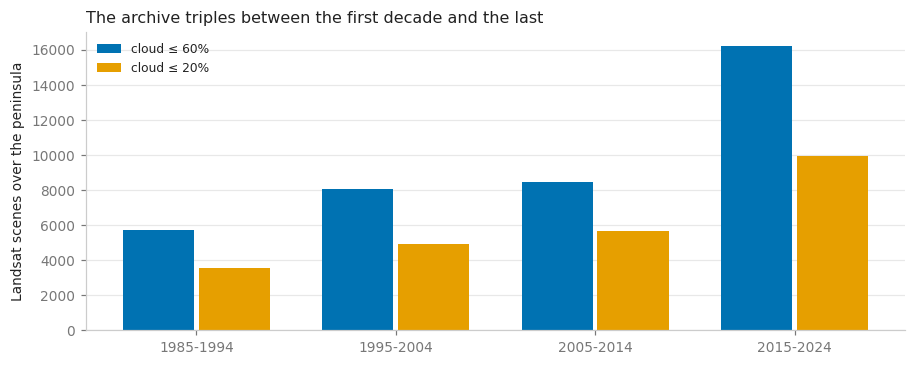

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
x = np.arange(len(LABELS))
width = 0.38
ax.bar(x - width / 2, scenes['cloud ≤ 60%'], width * 0.94, color=HUES[0],
       label='cloud ≤ 60%')
ax.bar(x + width / 2, scenes['cloud ≤ 20%'], width * 0.94, color=HUES[4],
       label='cloud ≤ 20%')
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Landsat scenes over the peninsula')
ax.set_title('The archive triples between the first decade and the last', loc='left',
             fontsize=10.5)
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

Landsat 5 flew alone over Iberia for most of the first decade. Landsat 7 joined in 1999 and
lost its scan line corrector in 2003; Landsat 8 arrived in 2013 and Landsat 9 in 2021, and
the last decade has two working sensors for all of it.

Keep the ratio in mind: roughly **three times** the observations in 2015-24 as in 1985-94.
Any statistic that depends on how many times a pixel was looked at will rise across these
four bars on its own.

Cloud filtering is left at `max_cloud_cover=60` throughout. The scene-level filter only
decides which scenes enter; `cloud_filter=True` still masks the cloudy *pixels* inside the
ones that do, which is what matters. Dropping to 20% would throw away a third of the early
record for no gain.

## 3. What a fire looks like, and what it does not

Sierra de la Culebra, in Zamora, burned between 15 and 18 June 2022 — around 25 000 ha, the
largest Spanish fire in decades. It is the right place to fix what "a burned pixel" means,
because MODIS mapped it independently and the answer is not in dispute.

The first candidate statistic is the one that suggests itself: the **annual minimum** of
NBR. Fire consumes vegetation, NBR collapses, so the year's lowest value should mark it.

In [6]:
def nbr(year, key, roi, percentile=None):
    """One NBR composite for one year: min, max, a percentile, or the count."""
    extra = {'percentile': percentile} if percentile is not None else {}
    return NdviSeasonality(roi=roi, sat='Landsat', index='nbr', key=key, periods=1,
                           start_year=year, end_year=year, cloud_filter=True,
                           max_cloud_cover=60, **extra).get_year_composite().first()


def burned_area(year, roi):
    """MCD64A1: where MODIS says something burned that year."""
    return (ee.ImageCollection('MODIS/061/MCD64A1')
            .filterDate(f'{year}-01-01', f'{year + 1}-01-01')
            .select('BurnDate').max().gt(0).unmask(0).clip(roi))


HECTARES = ee.Image.pixelArea().divide(1e4)

rows = []
for year in (2020, 2021, 2022, 2023):
    extremes = (nbr(year, 'max', CULEBRA).subtract(nbr(year, 'min', CULEBRA))
                .rename('amplitude'))
    stack = extremes.addBands(nbr(year, 'min', CULEBRA).rename('annual minimum'))
    scar = burned_area(year, CULEBRA)
    rows.append(ee.Feature(None, {'year': year})
                .set({'burned ha (MCD64A1)':
                      scar.multiply(HECTARES).reduceRegion(
                          ee.Reducer.sum(), CULEBRA, 500, maxPixels=1e9).values().get(0)})
                .set({'inside the scar': stack.updateMask(scar).reduceRegion(
                          ee.Reducer.mean(), CULEBRA, 300,
                          maxPixels=1e9).get('amplitude'),
                      'outside it': stack.updateMask(scar.Not()).reduceRegion(
                          ee.Reducer.mean(), CULEBRA, 300,
                          maxPixels=1e9).get('amplitude')}))
culebra = pd.DataFrame([f['properties'] for f in
                        ee.FeatureCollection(rows).getInfo()['features']])
culebra = culebra.set_index('year')[['burned ha (MCD64A1)', 'inside the scar',
                                     'outside it']]
culebra.round(3)

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2020: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2020: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2020: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using nbr index


,burned ha (MCD64A1),inside the scar,outside it
year,,,
2020,0.000,NaN,0.368
2021,0.000,NaN,0.436
2022,39968.868,0.832,0.389
2023,0.000,NaN,0.411


The table settles it. In 2022 MODIS maps **39 969 ha** burned inside the box, and the mean
NBR amplitude of those pixels is **0.83** against **0.39** for everything else in the same
scene, the same year, the same processing. In the three years without fire the outside
value barely moves — 0.37, 0.44, 0.41 — so that 0.39 is the ordinary seasonal travel of
this landscape, and the scar is at twice it.

The annual minimum on its own cannot do the same job, for a reason that has nothing to do
with sampling: a minimum is a **level**, and levels are not comparable between pixels. Open
water, a ploughed field and a fresh scar all sit low in NBR, and no threshold separates the
burnt one from the other two. The amplitude is a difference within the pixel's own year, so
each pixel carries its own reference.

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index


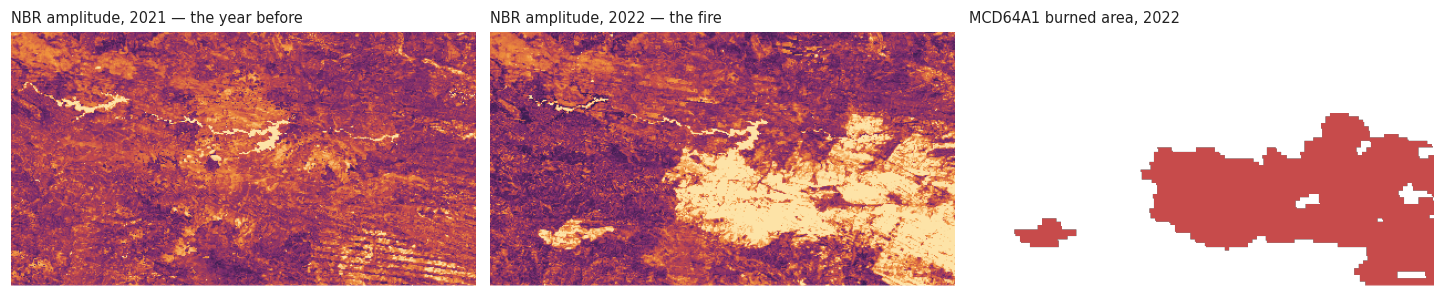

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6))
VIS = {'min': 0.1, 'max': 0.9, 'palette': BURN}
scar_2022 = burned_area(2022, CULEBRA)
outline = ee.Image().byte().paint(
    ee.FeatureCollection([ee.Feature(CULEBRA)]), 1, 1)

panels = [(nbr(2021, 'max', CULEBRA).subtract(nbr(2021, 'min', CULEBRA)),
           'NBR amplitude, 2021 — the year before'),
          (nbr(2022, 'max', CULEBRA).subtract(nbr(2022, 'min', CULEBRA)),
           'NBR amplitude, 2022 — the fire'),
          (scar_2022.selfMask(), 'MCD64A1 burned area, 2022')]

for ax, (image, title) in zip(axes, panels):
    vis = VIS if 'amplitude' in title else {'min': 0, 'max': 1, 'palette': ['c74b4b']}
    ax.imshow(thumbnail(image.clip(CULEBRA), vis, region=CULEBRA, dimensions=420))
    ax.set_title(title, loc='left', fontsize=9.5)
    ax.set_facecolor('#f2f2f0')
    ax.axis('off')
plt.tight_layout()

So the statistic that works is not the minimum on its own but the **within-year amplitude**:
how far NBR travelled inside a single year. A pixel that was green in spring and bare in
August has a large one; a pixel that stayed the same has a small one, whatever its absolute
level. It needs no reference image and no pairing of dates, which is what makes it
computable over forty years in one expression.

`NdviSeasonality` produces both ends directly — `key='max'` and `key='min'` over
`periods=1` — and their difference is the amplitude.

## 4. The trap: the amplitude moves with the number of looks

The amplitude as just defined is a difference of two extremes, and an extreme is the single
most sample-hungry statistic there is. Look at a pixel twice and you get a narrow range;
look at it thirty times and you will eventually catch it under a thin cloud, in a haze, at a
low sun angle. The range widens because the *sampling* widened, not because anything
happened on the ground.

Section 2 showed the archive tripling between the first decade and the last. If the
amplitude depends on the number of looks at all, the comparison across decades is in
trouble before it starts. So it is measured rather than assumed: unburned pixels only, in
one year, grouped by how many clear observations each of them actually had.

In [8]:
def amplitude(year, roi, robust=True):
    """Within-year NBR travel: p95 − p5 if robust, max − min otherwise."""
    if robust:
        return (nbr(year, 'percentile', roi, 95)
                .subtract(nbr(year, 'percentile', roi, 5)).rename('amplitude'))
    return nbr(year, 'max', roi).subtract(nbr(year, 'min', roi)).rename('amplitude')


looks = nbr(2022, 'count', CULEBRA).rename('looks')
unburned = burned_area(2022, CULEBRA).Not()
pair = (amplitude(2022, CULEBRA, robust=False).rename('max − min')
        .addBands(amplitude(2022, CULEBRA).rename('p95 − p5'))
        .addBands(looks).updateMask(unburned))

rows = []
for low, high in [(6, 12), (12, 18), (18, 24), (24, 30), (30, 60)]:
    window = pair.updateMask(looks.gte(low).And(looks.lt(high)))
    rows.append(ee.Feature(None, {'clear observations': '%d-%d' % (low, high)}).set(
        window.reduceRegion(ee.Reducer.mean(), CULEBRA, 300, maxPixels=1e9)))
bias = pd.DataFrame([f['properties'] for f in
                     ee.FeatureCollection(rows).getInfo()['features']])
bias = bias.set_index('clear observations')[['looks', 'max − min', 'p95 − p5']].dropna()
bias.round(3)

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index


,looks,max − min,p95 − p5
clear observations,,,
18-24,22.833,0.581,0.453
24-30,27.982,0.399,0.327
30-60,32.458,0.386,0.312


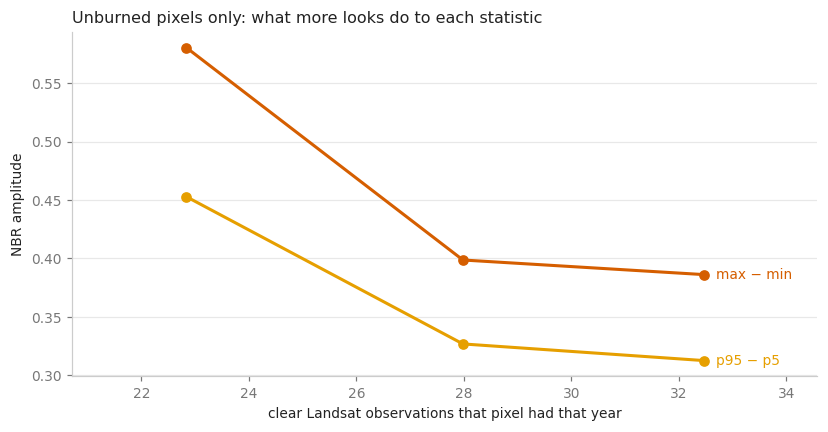

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 4))
for (name, values), hue in zip(bias[['max − min', 'p95 − p5']].items(), HUES[1::3]):
    ax.plot(bias['looks'], values, 'o-', ms=6, lw=2, color=hue)
    ax.annotate(name, (bias['looks'].iloc[-1], values.iloc[-1]), xytext=(8, 0),
                textcoords='offset points', fontsize=9, color=hue, va='center')
ax.set_xlabel('clear Landsat observations that pixel had that year')
ax.set_ylabel('NBR amplitude')
ax.set_title('Unburned pixels only: what more looks do to each statistic', loc='left',
             fontsize=10.5)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.22)
plt.tight_layout()

The measurement does not say what the argument above predicted, and that is worth stopping
on. Grouped by how many clear observations each unburned pixel had in 2022, the amplitude
**falls** as the looks pile up: 0.58 at 23 observations, 0.40 at 28, 0.39 at 32. The
percentile version behaves the same way, lower throughout (0.45 → 0.31).

The sampling argument is not wrong — the maximum of *n* draws does grow with *n* — but it
is not the only thing happening here. The number of clear looks a pixel gets is not handed
out at random: it tracks cloudiness, terrain and scene overlap, so it arrives bundled with
land cover. In a 30 × 55 km box that confound is stronger than the sampling effect, and it
points the other way.

For this notebook the sign hardly matters. What matters is the size: the amplitude of a
pixel that did not burn moves by **tens of percent** with the sampling alone, which is the
same order as the differences this notebook is about to compare between decades. An
absolute amplitude cannot be carried from one decade to the next, whichever way the bias
leans.

## 5. The mask: most of the big seasonal drops are harvests

The amplitude asks how far NBR travelled in a year, and a cereal field travels a very long
way: green in April, stubble in July. At peninsular scale those fields outnumber the fires
by orders of magnitude, and they repeat every single year.

The fix is a woody mask, and the obvious version of it — one modern land cover map applied
to all four decades — quietly assumes the landscape did not change in forty years. CORINE
has editions for **1990, 2000, 2006, 2012 and 2018**, all covering Spain and Portugal, so
each decade gets the land cover of its own time.

In [10]:
CORINE = {(1985, 1994): '1990', (1995, 2004): '2000',
          (2005, 2014): '2006', (2015, 2024): '2018'}

# forests, shrub and heath, transitional woodland, and the dehesa (244).
# 243 (agriculture with natural vegetation) and 321 (natural grassland) are left out:
# both burn, but both also carry an agricultural signal this notebook cannot separate
WOODY = [311, 312, 313, 322, 323, 324, 244]


def woody(decade):
    """The woody surface of the peninsula as CORINE saw it in that decade."""
    edition = ee.Image('COPERNICUS/CORINE/V20/100m/' + CORINE[decade])
    return edition.select('landcover').remap(WOODY, [1] * len(WOODY), 0).rename('woody')


cover = pd.Series({label: woody(decade).reduceRegion(
                       ee.Reducer.mean(), ROI, 2000, maxPixels=1e10,
                       bestEffort=True).getInfo()['woody']
                   for label, decade in zip(LABELS, DECADES)})
cover.round(3).to_frame('woody fraction of the ROI').T

,1985-1994,1995-2004,2005-2014,2015-2024
woody fraction of the ROI,0.457,0.457,0.47,0.47


There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index


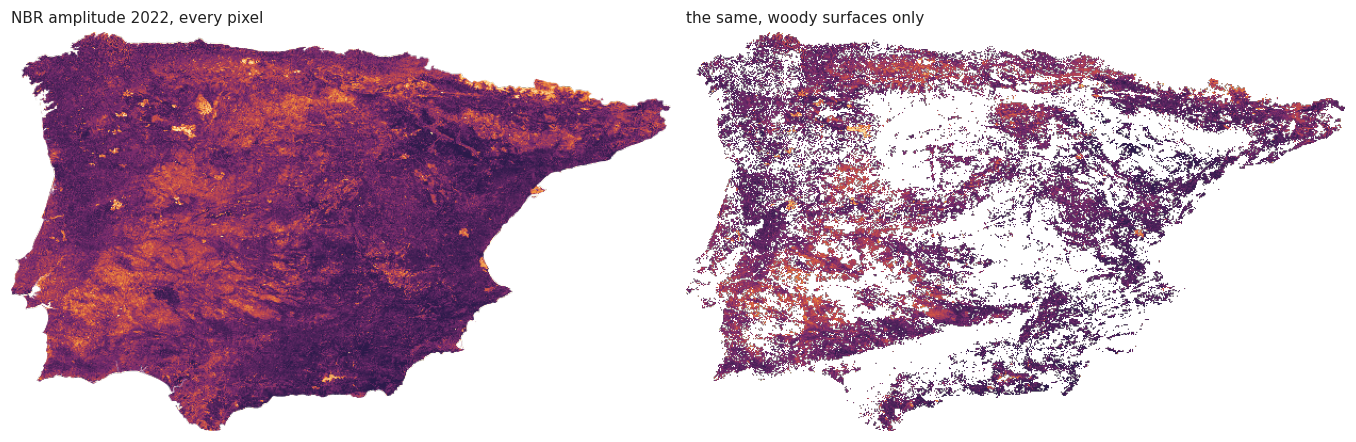

In [11]:
amp_2022 = amplitude(2022, ROI)
masked = amp_2022.updateMask(woody((2015, 2024)))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
for ax, (image, title) in zip(axes, [
        (amp_2022, 'NBR amplitude 2022, every pixel'),
        (masked, 'the same, woody surfaces only')]):
    ax.imshow(thumbnail(image, {'min': 0.1, 'max': 0.9, 'palette': BURN}))
    ax.set_title(title, loc='left', fontsize=10)
    ax.set_facecolor('#f2f2f0')
    ax.axis('off')
plt.tight_layout()

Half the peninsula disappears, and it is the half that was never going to be fire. What
survives is forest, shrub, heath and dehesa: 55.3 % of the surface in 1990 and 55.2 % in
2018, which is reassuringly stable for a mask that has to be comparable across four
decades.

## 6. An anomaly, not a level

There is one more problem, and this one is arithmetic rather than empirical: **a percentile
turns back into an extremum when there is little to take it from.** With six clear
observations in a year, p5 and p95 *are* the minimum and the maximum. The robust statistic
helps where the archive is thick and stops helping exactly where it is thin — which is the
first decade, the one the whole comparison depends on.

An absolute threshold on amplitude therefore cannot be carried across forty years. What can
be carried is a **contrast inside each decade**: how far a pixel's worst year departs from
its own ordinary year, in that same decade, seen by that same sensor with that same number
of looks. Sampling density lifts the worst year and the ordinary year together, and the
difference between them survives it.

So the quantity mapped from here on is

```
anomaly = amplitude of the worst year − amplitude of the median year
```

per pixel, per decade. A field harvested every year has a large amplitude and a *small*
anomaly; a hillside that burned once has both.

In [12]:
def decade_anomaly(decade, roi=None):
    """Worst year minus median year of NBR amplitude, inside one decade."""
    roi = ROI if roi is None else roi
    first, last = decade
    years = ee.ImageCollection([amplitude(year, roi)
                                for year in range(first, last + 1)])
    return (years.max().subtract(years.median()).rename('anomaly')
            .updateMask(woody(decade)))

The threshold still should not be chosen by eye. MCD64A1 maps burned area independently
from November 2000, so in the last decade the two can be crossed directly: bin the anomaly,
and ask what fraction of the pixels in each bin MODIS also calls burned. One grouped reducer
does the whole sweep in a single request.

In [13]:
amp = decade_anomaly((2015, 2024))
scar = ee.ImageCollection([burned_area(year, ROI)
                           for year in range(2015, 2025)]).max()

bins = amp.multiply(20).floor().int().rename('bin')       # bins 0.05 wide
# tileScale splits the computation into smaller pieces: a grouped reducer over the
# whole peninsula exceeds the memory of one worker without it
grouped = (scar.rename('burned').addBands(bins).reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True)
            .group(groupField=1, groupName='bin'),
    geometry=ROI, scale=1000, maxPixels=1e10, bestEffort=True,
    tileScale=16).getInfo()['groups'])

curve = pd.DataFrame(grouped).set_index('bin').sort_index()
curve.index = curve.index / 20
curve = curve.rename(columns={'mean': 'fraction MODIS calls burned',
                              'count': 'pixels'})
curve[curve['pixels'] > 50].round(4).head(24)

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2015: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2015: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2016: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2016: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using nbr index


,pixels,fraction MODIS calls burned
bin,,
0.00,49607,0.0040
0.05,128457,0.0069
0.10,74571,0.0149
0.15,36495,0.0336
0.20,19504,0.0704
0.25,12604,0.1291
0.30,9057,0.1886
0.35,6846,0.2408
0.40,5362,0.2971


In [14]:
# precision and recall for every candidate threshold, from the binned counts
truth = (curve['pixels'] * curve['fraction MODIS calls burned']).sum()
rows = []
for threshold in np.arange(0.05, 0.85, 0.05):
    above = curve[curve.index >= threshold]
    detected = above['pixels'].sum()
    hit = (above['pixels'] * above['fraction MODIS calls burned']).sum()
    rows.append({'threshold': round(threshold, 2),
                 'recall': hit / truth if truth else np.nan,
                 'precision': hit / detected if detected else np.nan})
skill = pd.DataFrame(rows).set_index('threshold')
skill['F1'] = 2 * skill['precision'] * skill['recall'] / (skill['precision'] + skill['recall'])
BEST = skill['F1'].idxmax()
print('best agreement with MCD64A1 at amplitude ≥ %.2f' % BEST)
skill.round(3)

best agreement with MCD64A1 at amplitude ≥ 0.30


,recall,precision,F1
threshold,,,
0.05,0.989,0.055,0.105
0.10,0.937,0.090,0.165
0.15,0.800,0.205,0.327
0.20,0.800,0.205,0.327
0.25,0.720,0.261,0.383
0.30,0.625,0.309,0.413
0.35,0.429,0.391,0.409
0.40,0.429,0.391,0.409
0.45,0.336,0.429,0.377


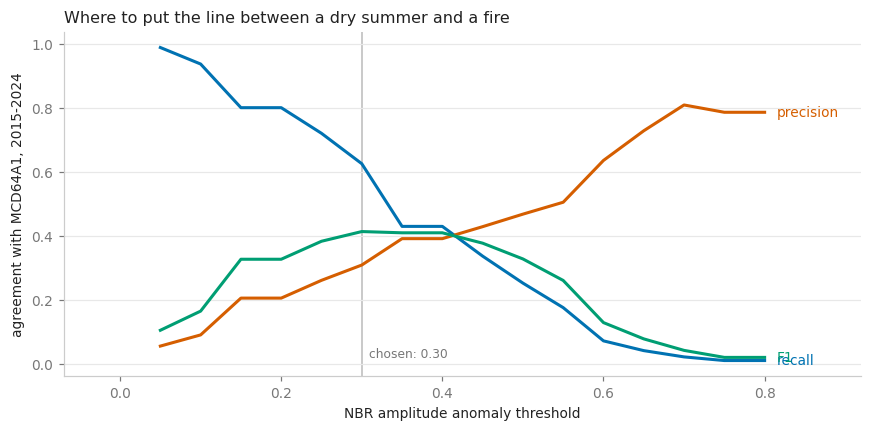

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for (name, values), hue in zip(skill[['recall', 'precision', 'F1']].items(), HUES):
    ax.plot(skill.index, values, '-', lw=2, color=hue)
    ax.annotate(name, (skill.index[-1], values.iloc[-1]), xytext=(8, 0),
                textcoords='offset points', fontsize=9, color=hue, va='center')
ax.axvline(BEST, color='#bbbbbb', lw=1, zorder=0)
ax.annotate('chosen: %.2f' % BEST, (BEST, 0.02), xytext=(5, 0),
            textcoords='offset points', fontsize=8, color=MUTED)
ax.set_xlabel('NBR amplitude anomaly threshold')
ax.set_ylabel('agreement with MCD64A1, 2015-2024')
ax.set_title('Where to put the line between a dry summer and a fire', loc='left',
             fontsize=10.5)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.16)
plt.tight_layout()

The sweep is unambiguous in one respect and sobering in another.

Unambiguous: the anomaly is strongly informative. The fraction of pixels that MODIS also
calls burned climbs monotonically with it, from **0.4 %** in the lowest bin to **92 %**
above 0.80. Nothing about that curve is noise.

Sobering: the best agreement is **F1 = 0.41, at an anomaly of 0.30** — recall 0.63,
precision 0.31. The same statistic scored 0.93 on the Sierra de la Culebra box. The
detector did not get worse; the **base rate** did. In that box roughly a quarter of the
area had burned, while over the woody peninsula MODIS maps 4.8 % as burned at some point in
2015-24 (1.71 Mha). Precision is bounded by prevalence: to recover 63 % of a 4.8 % target
you must flag about 10 % of the map, and two of every three flagged pixels are then
something else — a clear-cut, a drought year in a cork oak stand, a shrubland cleared by
machine.

So 0.30 is the threshold this notebook uses, and the maps that follow are honest maps of
*where something happened*. The hectares they imply are not burned area, and section 9
measures how far off they are.

## 7. The four decades

Everything is now in place: a robust amplitude, a contemporaneous woody mask, and a
threshold calibrated against an independent product. A pixel counts as burned in a decade
if its **anomaly** — the amplitude of its worst year minus that of its median year —
crosses 0.30.

> **This is the expensive part.** Ten years of two percentile composites each, for four
> decades, over the peninsula. Building the graphs alone takes eight minutes — eighty
> `NdviSeasonality` objects, each of which asks Earth Engine what it has — and the table
> that follows takes another five. Every reducer from here on carries `tileScale`: without
> it the grouped reducer of section 6 fails with *User memory limit exceeded*.

In [16]:
anomaly, burned, looks_per_decade = {}, {}, {}
for label, decade in zip(LABELS, DECADES):
    first, last = decade
    anomaly[label] = decade_anomaly(decade)
    burned[label] = anomaly[label].gte(BEST).selfMask().rename('burned')
    looks_per_decade[label] = ee.ImageCollection(
        [nbr(year, 'count', ROI).rename('looks')
         for year in range(first, last + 1)]).mean().updateMask(woody(decade))
print('graphs built; nothing computed yet — Earth Engine is lazy')

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1985: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1985: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1986: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1986: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2020: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using nbr index
graphs built; nothing computed yet — Earth Engine is lazy


In [17]:
# one request per decade rather than one for all four: a decade is twenty percentile
# composites of the whole peninsula, and bundling eighty of them into a single call
# returns nothing until the last one lands
rows = []
for label, decade in zip(LABELS, DECADES):
    woody_ha = woody(decade).selfMask().multiply(HECTARES)
    burned_ha = burned[label].updateMask(woody(decade)).multiply(HECTARES)
    clock = time.time()
    rows.append(ee.Feature(None, {'decade': label}).set({
        'woody ha': woody_ha.reduceRegion(ee.Reducer.sum(), ROI, 1000, maxPixels=1e10,
                                          bestEffort=True, tileScale=16).values().get(0),
        'burned ha': burned_ha.reduceRegion(ee.Reducer.sum(), ROI, 1000, maxPixels=1e10,
                                            bestEffort=True,
                                            tileScale=16).values().get(0)}
                ).getInfo()['properties'])
    print('%s   %.0f s' % (label, time.time() - clock))

decades = pd.DataFrame(rows).set_index('decade')
decades['% of woody surface'] = 100 * decades['burned ha'] / decades['woody ha']
decades = decades.loc[LABELS]
decades.round(1)

1985-1994   42 s


1995-2004   73 s


2005-2014   83 s


2015-2024   109 s


,burned ha,woody ha,% of woody surface
decade,,,
1985-1994,5211225.9,26535329.8,19.6
1995-2004,4404635.1,26527500.0,16.6
2005-2014,4487296.8,27016616.9,16.6
2015-2024,2616916.3,26981244.7,9.7


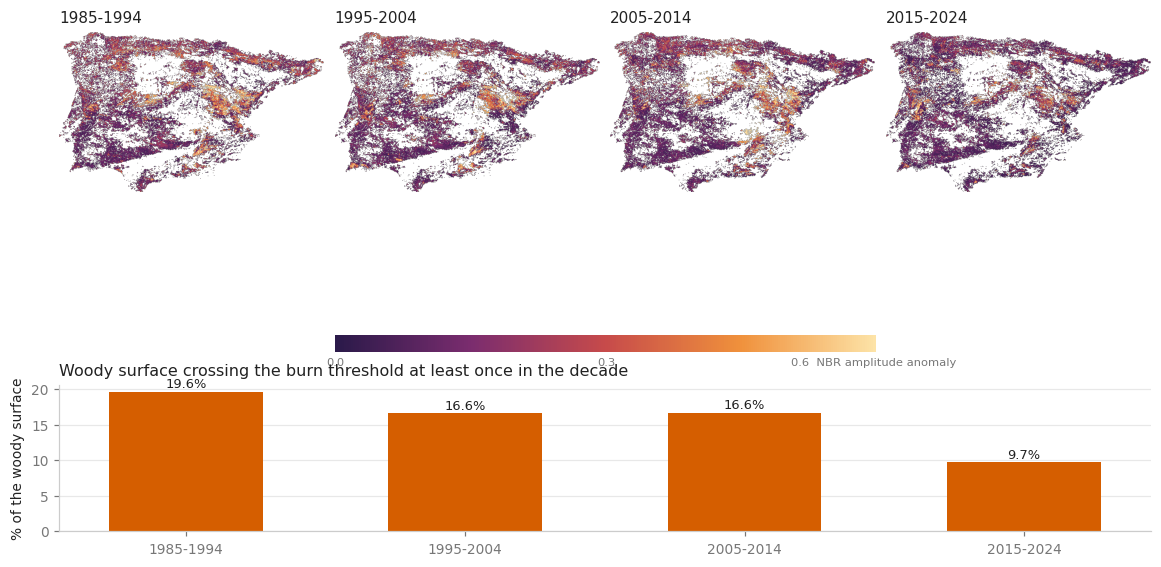

In [18]:
fig = plt.figure(figsize=(12.8, 7.2))
grid = fig.add_gridspec(3, 4, height_ratios=[13, 0.6, 5], hspace=0.18, wspace=0.04)

for column, label in enumerate(LABELS):
    ax = fig.add_subplot(grid[0, column])
    ax.imshow(thumbnail(anomaly[label], {'min': 0, 'max': 0.6, 'palette': BURN},
                        dimensions=520))
    ax.set_title(label, loc='left', fontsize=10)
    ax.set_facecolor('#f2f2f0')
    ax.axis('off')
ramp_legend(fig.add_subplot(grid[1, 1:3]), BURN, [0, 128, 255],
            ['0.0', '0.3', '0.6  NBR amplitude anomaly'])

ax = fig.add_subplot(grid[2, :])
ax.bar(LABELS, decades['% of woody surface'], 0.55, color=HUES[1])
for label, value in decades['% of woody surface'].items():
    ax.annotate('%.1f%%' % value, (label, value), xytext=(0, 3),
                textcoords='offset points', ha='center', fontsize=8.5, color=INK)
ax.set_ylabel('% of the woody surface')
ax.set_title('Woody surface crossing the burn threshold at least once in the decade',
             loc='left', fontsize=10.5)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)

The maps are worth looking at before the table. Each one finds the fires of its decade
where the fires of that decade were — the northwest, the Portuguese interior, the
Mediterranean strip — and the shapes are scars, not noise. Within a decade, the method
works.

The table is another matter. It runs **downwards**: 19.6 % of the woody peninsula in
1985-94, 16.6 % in each of the two middle decades, **9.7 %** in 2015-24. Read literally,
Iberia burned half as much in the last decade as in the first, which is the opposite of
what anyone who lived through the last few summers would say.

And the first number cannot be true in any reading. 19.6 % of 26.5 Mha is **5.2 million
hectares** of burned woody surface in ten years. For the one decade where an independent
product exists, MCD64A1 maps 1.71 Mha over the same mask — so the 1985-94 figure is three
times a *measured* decade, with half the satellite coverage behind it.

## 8. How many looks did each decade actually get?

The anomaly is built to survive a change in sampling density, but "built to" is not "does".
The number of clear observations per pixel-year is the covariate to report next to the
trend, so a reader can see how far the four decades are from comparable.

In [19]:
rows = []
for label in LABELS:
    clock = time.time()
    rows.append(ee.Feature(None, {'decade': label}).set(
        looks_per_decade[label].reduceRegion(
            ee.Reducer.mean(), ROI, 2000, maxPixels=1e10, bestEffort=True,
            tileScale=16)).getInfo()['properties'])
    print('%s   %.0f s' % (label, time.time() - clock))

looks_table = pd.DataFrame(rows).set_index('decade').loc[LABELS]
looks_table = looks_table.rename(columns={'looks': 'clear observations per pixel-year'})
looks_table.round(1)

1985-1994   24 s


1995-2004   56 s


2005-2014   34 s


2015-2024   35 s


,clear observations per pixel-year
decade,
1985-1994,15.7
1995-2004,21.2
2005-2014,21.5
2015-2024,40.7


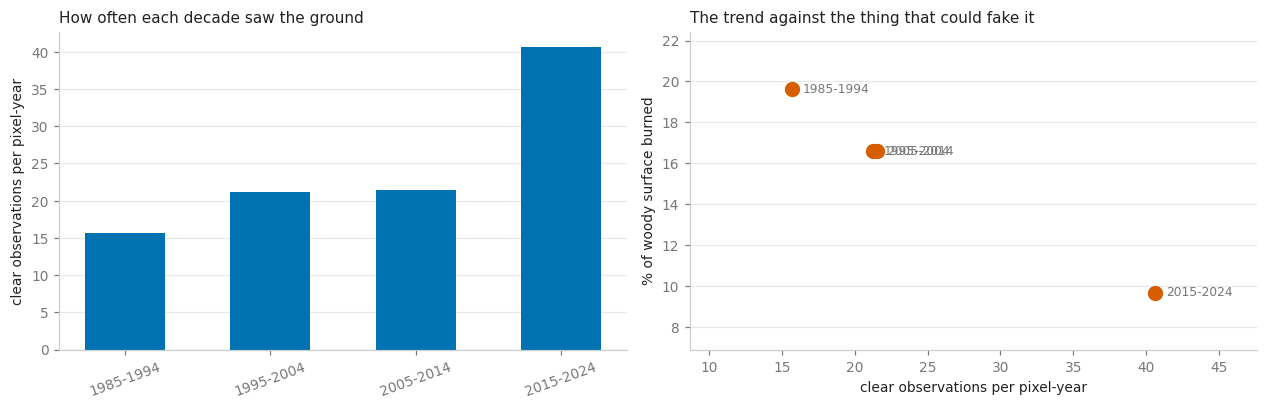

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.8))
axes[0].bar(LABELS, looks_table.iloc[:, 0], 0.55, color=HUES[0])
axes[0].set_ylabel('clear observations per pixel-year')
axes[0].set_title('How often each decade saw the ground', loc='left', fontsize=10)
axes[0].tick_params(axis='x', labelrotation=20)

axes[1].plot(looks_table.iloc[:, 0], decades['% of woody surface'], 'o', ms=9,
             color=HUES[1])
for label in LABELS:
    axes[1].annotate(label, (looks_table.loc[label].iloc[0],
                             decades.loc[label, '% of woody surface']),
                     xytext=(7, 0), textcoords='offset points', fontsize=8,
                     color=MUTED, va='center')
axes[1].set_xlabel('clear observations per pixel-year')
axes[1].set_ylabel('% of woody surface burned')
axes[1].set_title('The trend against the thing that could fake it', loc='left',
                  fontsize=10)
axes[1].margins(x=0.28, y=0.28)

for ax in axes:
    ax.grid(axis='y', lw=0.8)
    ax.set_axisbelow(True)
plt.tight_layout()

Here is the whole problem on one pair of axes. Clear observations per pixel-year:
**15.7 → 21.2 → 21.5 → 40.7**. Share of woody surface called burned: **19.6 → 16.6 → 16.6
→ 9.7 %**. The four decades line up almost perfectly, and in the wrong direction: the more
often a decade was looked at, the less of it this method calls burned.

That is the signature of a sampling artefact, and it agrees with the box measurement of
section 4, where the amplitude of unburned pixels also fell as the looks piled up. The
anomaly was built to divide that bias out — the worst year and the ordinary year are lifted
together, and the difference should survive — and over four decades of a changing
constellation, it does not survive enough.

## 9. Does it agree with MODIS where they overlap?

MCD64A1 starts in November 2000, so it covers the last two decades of this record and
nothing before. That is not enough to validate the trend — which is exactly the point of
running the check, because the two decades it *can* see are the two the Landsat archive is
thickest in.

In [21]:
# MCD64A1 starts in November 2000, so only the years both records cover are compared,
# on both sides. Crossing a full Landsat decade against four years of MODIS was the first
# version of this cell, and it inflated the disagreement roughly threefold.
rows = []
for label, decade in zip(LABELS, DECADES):
    first, last = decade
    common = [year for year in range(first, last + 1) if year >= 2001]
    if len(common) < 4:
        continue
    years = ee.ImageCollection([amplitude(year, ROI) for year in common])
    landsat = (years.max().subtract(years.median()).updateMask(woody(decade))
               .gte(BEST).selfMask())
    modis = (ee.ImageCollection([burned_area(year, ROI) for year in common]).max()
             .selfMask().updateMask(woody(decade)))
    clock = time.time()
    rows.append(ee.Feature(None, {'decade': label,
                                  'years': '%d-%d' % (common[0], common[-1])}).set({
        'Landsat ha': landsat.multiply(HECTARES).reduceRegion(
            ee.Reducer.sum(), ROI, 1000, maxPixels=1e10, bestEffort=True,
            tileScale=16).values().get(0),
        'MCD64A1 ha': modis.multiply(HECTARES).reduceRegion(
            ee.Reducer.sum(), ROI, 1000, maxPixels=1e10, bestEffort=True,
            tileScale=16).values().get(0)}).getInfo()['properties'])
    print('%s   %.0f s' % (label, time.time() - clock))

comparison = pd.DataFrame(rows).set_index('decade')
comparison['Landsat ÷ MODIS'] = comparison['Landsat ha'] / comparison['MCD64A1 ha']
comparison[['years', 'Landsat ha', 'MCD64A1 ha', 'Landsat ÷ MODIS']].round(2)

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2001: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2001: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2002: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2002: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2023: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using nbr index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using nbr index


2015-2024   58 s


,years,Landsat ha,MCD64A1 ha,Landsat ÷ MODIS
decade,,,,
1995-2004,2001-2004,2307697.24,789442.12,2.92
2005-2014,2005-2014,4487296.82,1125698.95,3.99
2015-2024,2015-2024,2616916.34,1295996.79,2.02


Restricted to the years both records cover, the Landsat anomaly maps **2.9, 4.0 and 2.0
times** as much burned surface as MCD64A1. Two things follow, and the second is the more
useful.

The first: the overestimate is not a constant. If it were, it would be a calibration
factor and the decade series could be rescaled. It is 4.0 in one decade and 2.0 in the
next, which is the same size as the "trend" the series was supposed to show. There is
nothing to rescale.

The second: **MODIS can answer the original question for the years it covers, and it does
not agree with the Landsat series either.** Per year of its own record, MCD64A1 maps about
197 000 ha/yr in 2001-04 (four years that include the catastrophic 2003 and 2004 in
Portugal), **112 600 ha/yr in 2005-14 and 129 600 ha/yr in 2015-24**. The last decade burns
about **15 % more per year** than the one before it — a real increase, modest, and the
opposite in sign to the 19.6 → 9.7 % the Landsat anomaly produced.

## 10. What to take away

**On the method.**

1. For fire, the usable NBR statistic is the **within-year amplitude**, not the minimum: a
   minimum is a level, and water, bare soil and a fresh scar all sit low. On Sierra de la
   Culebra the amplitude reads 0.83 inside the 2022 scar against 0.39 outside.
2. A **woody mask of the right vintage** is not optional at this scale. Without it the
   biggest seasonal drops in NBR are harvests, and they repeat every year. CORINE gives
   each decade a contemporaneous one.
3. The level of the amplitude cannot be carried across decades, so what is mapped is a
   **within-decade anomaly**: worst year minus median year.
4. Calibrate the threshold against an independent product, and expect precision to follow
   the **base rate**. The same anomaly scores F1 0.93 on a box where a quarter of the area
   burned and F1 0.41 over a peninsula where 4.8 % did.
5. Every peninsula-wide reducer needs `tileScale`. Without it the grouped reducer of
   section 6 fails outright.

**On the answer.**

The maps this notebook produces are good maps of where Iberia burned, decade by decade.
The *series* across them is not a measurement of fire: the four decades line up against
the number of clear looks each one got — 15.7 to 40.7 observations per pixel-year against
19.6 % to 9.7 % of the woody surface — and the Landsat-to-MODIS ratio swings between 2.0
and 4.0 in the two decades where it can be checked.

So the honest answer to "does Iberia burn more than it used to" is that **this archive
cannot say**, not before 2001. Where a purpose-built product exists it can: MCD64A1 puts
the last decade about 15 % per year above the one before it. That is a smaller and duller
number than a forty-year Landsat trend would have been, and it is the one that survives
being checked.

A notebook that ends by discarding its own headline is not a failed notebook. The three
fixes in sections 3 to 6 are real and they transfer to any long optical series; what does
not transfer is the assumption that a sensor record is a stable instrument across forty
years. Report the observation count next to the number, always.